In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

import seaborn as sns

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join, Column, unique
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
from tqdm import tqdm
import seaborn as sns
plt.rcParams['text.usetex'] = False
pf.housestyle_rcparams()

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
# sys.path.append('../../../')
# import src.ifu_tools.line_ratios as lr
# import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings('ignore', message='The following kwargs were not used by contour')
import pickle

from dynesty import plotting as dyplot
import dynesty



In [28]:
# Load it back
with open('dynesty_results.pkl', 'rb') as f:
    results = pickle.load(f)
from math import floor, log10

    

In [29]:
def round_to_1sf_of(ref):
    """Return the number of decimal places needed to express ref to 1 s.f."""
    if ref == 0:
        return 0
    mag = floor(log10(abs(ref)))
    return max(0, -mag)


def format_title(val, low, high):
    """
    Round each error to 1 s.f., then round val to match the precision of
    whichever rounded error is more precise (i.e. more decimal places).
    """
    def round_err_to_1sf(e):
        if e == 0:
            return 0.0, 0
        mag   = floor(log10(abs(e)))
        scale = 10 ** mag
        rounded = round(e / scale) * scale
        dp = max(0, -mag)
        return rounded, dp

    low_r,  dp_low  = round_err_to_1sf(low)
    high_r, dp_high = round_err_to_1sf(high)
    dp = max(dp_low, dp_high)

    val_r = round(val, dp)
    fmt = f'{{:.{dp}f}}'
    return f'${fmt.format(val_r)}^{{+{fmt.format(high_r)}}}_{{-{fmt.format(low_r)}}}$'

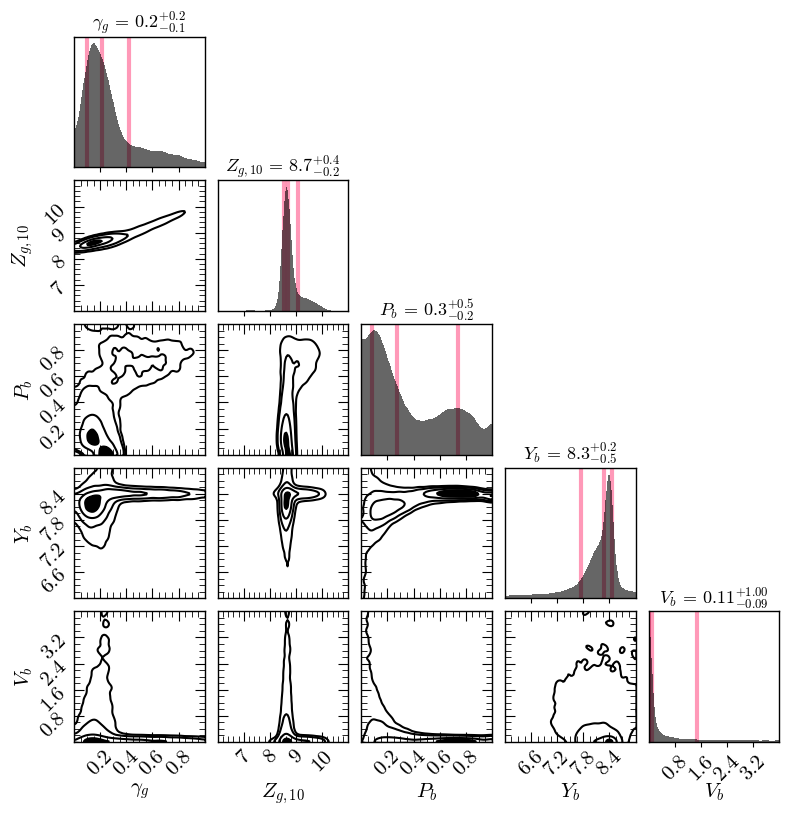

In [52]:
param_labels = [r"$\gamma_g$", r"$Z_{g,10}$", r"$P_b$", r"$Y_b$", r"$V_b$"]
ndim = len(param_labels)
fig, axes = plt.subplots(ndim, ndim, figsize=(8, 8))
fig, axes = dyplot.cornerplot(results, labels=param_labels, show_titles=True,
                               title_kwargs={"fontsize": 15},
                               fig=(fig, axes))
fig.subplots_adjust(wspace=0.1,hspace=0.1)

list_of_axes = []
for i in range(len(param_labels)):
    for j in range(len(param_labels)):
        if i != j:
            list_of_axes.append(axes[i, j])

weights = np.exp(results.logwt - results.logz[-1])  # normalised weights

custom_quantiles = {
    0: [0.16, 0.50, 0.80],
}
default_quantiles = [0.16, 0.50, 0.84]

for i in range(ndim):
    ax = axes[i, i]
    qs = custom_quantiles.get(i, default_quantiles)
    q_lo, q50, q_hi = dynesty.utils.quantile(results.samples[:, i], qs, weights=weights)

    # Remove existing quantile lines dyplot drew
    for line in ax.lines[:]:
        line.remove()   

    # Redraw with your quantiles
    ax.set_ylim(*ax.get_ylim())

    ymin, ymax = ax.get_ylim()
    for q in [q_lo, q50, q_hi]:
        ax.axvline(q, ymin=-10, ymax=10, color="#ff004f", ls="-", lw=3, alpha=0.4,zorder=-10)

    low  = q50 - q_lo
    high = q_hi - q50
    title = format_title(q50, low, high)
    title = f"{param_labels[i]} = {title}"
    ax.set_title(title, fontsize=13)

pf.fix_plot(list_of_axes)
fig.savefig(f'figs/kalcorner.pdf', dpi=600, bbox_inches='tight')